# Fine-tuning a Pre-trained Convolutional Neural Network for the Grainset Image Dataset

For our Neural Network, we will use a pre-trained model in order to perform classification tasks. We chose a CNN model, especifically EfficientNetV2-small, in order to utilize its convolutional blocks that can extract features from the images.

In [1]:
import matplotlib.pyplot as plt
from neural_network_utils import (
    GrainDataModule,
    IDX_TO_CLASS,
    LightningModel,
    plot_loss_and_acc,
)
import lightning as L
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext watermark
%watermark -p torch,lightning,torchvision


torch      : 2.10.0
lightning  : 2.6.1
torchvision: 0.25.0



## Preparing the Pre-Trained Model

In [3]:
efficientnet_v2_s = torch.hub.load(
    "pytorch/vision:v0.25.0", "efficientnet_v2_s", weights="IMAGENET1K_V1"
)

Using cache found in /home/xandreiathome/.cache/torch/hub/pytorch_vision_v0.25.0


In [4]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [5]:
for param in efficientnet_v2_s.parameters():
    param.requires_grad = False

# EfficientNet's final layer is classifier[1], not fc
efficientnet_v2_s.classifier[1] = torch.nn.Linear(1280, 16)

In [6]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [7]:
from torchvision.models import EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Preparing the Dataset and Loaders
A quick check in order to make sure that the dataloader is able to load the images properly

In [8]:
data_module = GrainDataModule(
    data_dir="dataset/images",
    batch_size=32,
    train_transform=preprocess_transform,
    val_transform=preprocess_transform,
    test_transform=preprocess_transform,
)

In [9]:
data_module.setup()

In [10]:
print("Train size:", len(data_module.train_dataset))
print("Val size:", len(data_module.val_dataset))
print("Test size:", len(data_module.test_dataset))

Train size: 38220
Val size: 6742
Test size: 5000


In [11]:
train_loader = data_module.train_dataloader()

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 384, 384])
torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2710083].


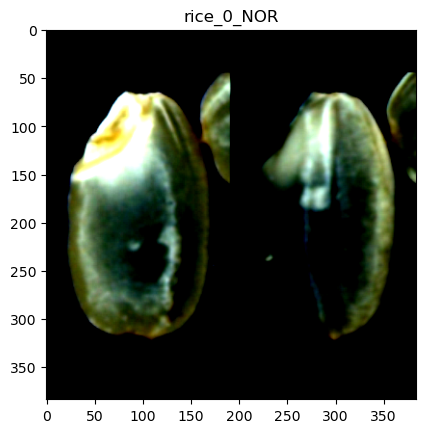

In [12]:
img = images[0].permute(1, 2, 0)

plt.imshow(img)
plt.title(IDX_TO_CLASS[labels[0].item()])
plt.show()

# Fine Tuning the Model

In [ ]:
L.seed_everything(67)

lightning_model = LightningModel(
    model=efficientnet_v2_s, learning_rate=0.01, num_classes=16
)

trainer = L.Trainer(
    max_epochs=3,
    accelerator="gpu",
    devices="auto",
    logger=CSVLogger(save_dir="logs/", name="tuned-efficientnet"),
    deterministic=True,
)

Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [18]:
trainer.fit(model=lightning_model, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                    │ EfficientNet        │ 20.2 M │ train │     0 │
│ 1 │ train_acc                │ MulticlassAccuracy  │      0 │ train │     0 │
│ 2 │ val_acc                  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3 │ test_acc                 │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ test_precision           │ MulticlassPrecision │      0 │ train │     0 │
│ 5 │ test_recall              │ MulticlassRecall    │      0 │ train │     0 │
│ 6 │ test_f1                  │ MulticlassF1Score   │      0 │ train │     0 │
│ 7 │ test_precision_per_class │ MulticlassPrecision │      0 │ train │     0 │
│ 8 │ test_recall_per_class    │ MulticlassRecall    │      0 │ train │     0 │
│ 9 │ test_f1_per_class        │ MulticlassF1Score   │      0 │ train │     0 │
└───┴──────────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 20.5 K                                                                                           
Non-trainable params: 20.2 M                                                                                       
Total params: 20.2 M                                                                                               
Total estimated model params size (MB): 80                                                                         
Modules in train mode: 723                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
trainer.test(model=lightning_model, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │            0.0            │
│          test_f1          │            0.0            │
│      test_f1_class_0      │            0.0            │
│      test_f1_class_1      │            0.0            │
│     test_f1_class_10      │            0.0            │
│     test_f1_class_11      │            0.0            │
│     test_f1_class_12      │            0.0            │
│     test_f1_class_13      │            0.0            │
│     test_f1_class_14      │            0.0            │
│     test_f1_class_15      │            0.0            │
│      test_f1_class_2      │            0.0            │
│      test_f1_class_3      │            0.0            │
│      test_f1_class_4      │            0.0            │
│      test_f1_class_5      │            0.0            │
│      test_f1_class_6      │            0.0            │
│      test_f1_class_7      │            0.0            │
│      test_f1_class_8      │            0.0            │
│      test_f1_class_9      │            0.0            │
│      test_precision       │            0.0            │
│  test_precision_class_0   │            0.0            │
│  test_precision_class_1   │            0.0            │
│  test_precision_class_10  │            0.0            │
│  test_precision_class_11  │            0.0            │
│  test_precision_class_12  │            0.0            │
│  test_precision_class_13  │            0.0            │
│  test_precision_class_14  │            0.0            │
│  test_precision_class_15  │            0.0            │
│  test_precision_class_2   │            0.0            │
│  test_precision_class_3   │            0.0            │
│  test_precision_class_4   │            0.0            │
│  test_precision_class_5   │            0.0            │
│  test_precision_class_6   │            0.0            │
│  test_precision_class_7   │            0.0            │
│  test_precision_class_8   │            0.0            │
│  test_precision_class_9   │            0.0            │
│        test_recall        │            0.0            │
│    test_recall_class_0    │            0.0            │
│    test_recall_class_1    │            0.0            │
│   test_recall_class_10    │            0.0            │
│   test_recall_class_11    │            0.0            │
│   test_recall_class_12    │            0.0            │
│   test_recall_class_13    │            0.0            │
│   test_recall_class_14    │            0.0            │
│   test_recall_class_15    │            0.0            │
│    test_recall_class_2    │            0.0            │
│    test_recall_class_3    │            0.0            │
│    test_recall_class_4    │            0.0            │
│    test_recall_class_5    │            0.0            │
│    test_recall_class_6    │            0.0            │
│    test_recall_class_7    │            0.0            │
│    test_recall_class_8    │            0.0            │
│    test_recall_class_9    │            0.0            │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.0,
  'test_precision': 0.0,
  'test_recall': 0.0,
  'test_f1': 0.0,
  'test_precision_class_0': 0.0,
  'test_recall_class_0': 0.0,
  'test_f1_class_0': 0.0,
  'test_precision_class_1': 0.0,
  'test_recall_class_1': 0.0,
  'test_f1_class_1': 0.0,
  'test_precision_class_2': 0.0,
  'test_recall_class_2': 0.0,
  'test_f1_class_2': 0.0,
  'test_precision_class_3': 0.0,
  'test_recall_class_3': 0.0,
  'test_f1_class_3': 0.0,
  'test_precision_class_4': 0.0,
  'test_recall_class_4': 0.0,
  'test_f1_class_4': 0.0,
  'test_precision_class_5': 0.0,
  'test_recall_class_5': 0.0,
  'test_f1_class_5': 0.0,
  'test_precision_class_6': 0.0,
  'test_recall_class_6': 0.0,
  'test_f1_class_6': 0.0,
  'test_precision_class_7': 0.0,
  'test_recall_class_7': 0.0,
  'test_f1_class_7': 0.0,
  'test_precision_class_8': 0.0,
  'test_recall_class_8': 0.0,
  'test_f1_class_8': 0.0,
  'test_precision_class_9': 0.0,
  'test_recall_class_9': 0.0,
  'test_f1_class_9': 0.0,
  'test_precision_class_10

In [ ]:
plot_loss_and_acc(log_dir=trainer.logger.log_dir, loss_ylim=(0.0, 2.0))

FileNotFoundError: [Errno 2] No such file or directory: 'None/metrics.csv'